<a href="https://colab.research.google.com/github/edumabagraham/understanding_mthars/blob/main/MTHARS_vs_SKNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MTHARS vs. the SK network on UCI-HAR

Two papers, one backbone:

> W. Gao, L. Zhang, W. Huang, F. Min, J. He and A. Song, "Deep Neural Networks
> for Sensor-Based Human Activity Recognition Using Selective Kernel
> Convolution," *IEEE TIM*, vol. 70, 2021. **(SK network)**

> J. Duan et al., "A Multi-Task Deep Learning Approach for Sensor-based Human
> Activity Recognition and Segmentation," 2023. **(MTHARS)**

MTHARS Sec. III-C: *"The MTHARS approach consists of the SK network [44] as a
backbone network, the Windows Generate module and the recognition and
segmentation module."* So the SK network is not a competitor to MTHARS, it is
the first third of it. What MTHARS adds is the ability to work on an
**unsegmented stream**: rather than classifying a window somebody else cut, it
predicts where each activity starts and ends *and* what it is, in one pass.

### What is in the repository

| File | Contents |
|---|---|
| `mthars.py` | `SKUnit`, `SKConv`, `SKNet`; window generation, IoU, offset coding, matching, the recognition/segmentation head, the multi-task loss, NMS, and the NED / weighted-F1 metrics |
| `har_data.py` | UCI-HAR download, the window view, stream reconstruction, the stream dataset, and the sliding-window baseline decoder |
| `compare.py` | Trains both models and scores them on identical test streams |
| `test_mthars.py` | 33 unit tests over every piece above |

The notebook drives those modules rather than redefining the classes, so there
is a single source of truth for the architecture.

## Running this notebook

The repository is **private**, which is why a plain Colab run cannot fetch the
modules — `raw.githubusercontent.com` answers 404 to an unauthenticated runtime.
Pick whichever is least effort for you:

1. **Make the repository public** (Settings → General → Danger Zone → Change
   visibility). The setup cell then works with no token.
2. **Add a token to Colab Secrets** — the key icon in the left sidebar, name it
   `GITHUB_TOKEN`, value a fine-grained PAT with read access to this repository,
   and enable notebook access. Nothing is pasted into the notebook.
3. **Upload the four `.py` files** when the setup cell offers a file picker.
4. **Run locally instead**, which avoids all of this:

   ```bash
   git clone https://github.com/edumabagraham/understanding_mthars
   cd understanding_mthars
   pip install torch numpy matplotlib requests
   python test_mthars.py          # 33 tests, no dataset needed
   python compare.py --epochs 30  # downloads UCI-HAR, trains both, prints the table
   ```

A GPU runtime is worth selecting (Runtime → Change runtime type): MTHARS trains
on 1024-timestep streams, which is slow on CPU.

In [ ]:
# ---------------------------------------------------------------------------
# Setup: make mthars.py, har_data.py, compare.py and test_mthars.py importable.
#
# The repository is PRIVATE, so raw.githubusercontent.com returns "404: Not
# Found" to an unauthenticated Colab runtime. Three ways to get the modules,
# tried in order:
#   1. They are already next to the notebook (running locally, or Drive-mounted).
#   2. A GitHub token in Colab Secrets (key icon in the sidebar) named
#      GITHUB_TOKEN, with `repo` scope -- or make the repository public, and no
#      token is needed.
#   3. Upload them by hand; the cell offers a file picker as a last resort.
# ---------------------------------------------------------------------------
import ast
import os
from pathlib import Path

REPO = "edumabagraham/understanding_mthars"
BRANCH = "main"
MODULES = ("mthars.py", "har_data.py", "compare.py", "test_mthars.py")


def is_usable(module: str) -> bool:
  """True if the file exists and is real Python (not a saved 404 page)."""
  path = Path(module)
  if not path.is_file():
    return False
  try:
    ast.parse(path.read_text())
    return True
  except (SyntaxError, UnicodeDecodeError):
    path.unlink()   # a previous run saved an error page here; get rid of it
    return False


def try_download(module: str, token: str) -> bool:
  import requests
  url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{module}"
  headers = {"Authorization": f"Bearer {token}"} if token else {}
  try:
    response = requests.get(url, headers=headers, timeout=60)
  except Exception:
    return False
  if response.status_code != 200:
    return False
  Path(module).write_text(response.text)
  return is_usable(module)


missing = [m for m in MODULES if not is_usable(m)]

if missing:
  token = os.environ.get("GITHUB_TOKEN", "")
  if not token:
    try:
      from google.colab import userdata
      token = userdata.get("GITHUB_TOKEN")
    except Exception:
      token = ""

  missing = [m for m in missing if not try_download(m, token)]
  if missing and not token:
    print("Could not fetch from GitHub. The repository is private, so this "
          "needs either a GITHUB_TOKEN in Colab Secrets or a public repo.\n")

if missing:
  try:
    from google.colab import files
    print(f"Upload these files: {', '.join(missing)}")
    files.upload()
  except ImportError:
    pass
  missing = [m for m in MODULES if not is_usable(m)]

if missing:
  raise RuntimeError(
      f"still missing: {', '.join(missing)}. Download them from "
      f"https://github.com/{REPO} and upload them next to this notebook.")

print("modules ready:", ", ".join(MODULES))

# ---------------------------------------------------------------------------
import torch
from torch import nn
import matplotlib.pyplot as plt

import har_data
import mthars
from mthars import MTHARS, SKNet

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"PyTorch {torch.__version__} | device: {device}")

In [ ]:
# The implementation ships with tests. Run them first -- if the architecture is
# wrong, nothing downstream is worth reading.
!python test_mthars.py 2>&1 | tail -40

# 1. The backbone: Gao's SK network

## Architecture

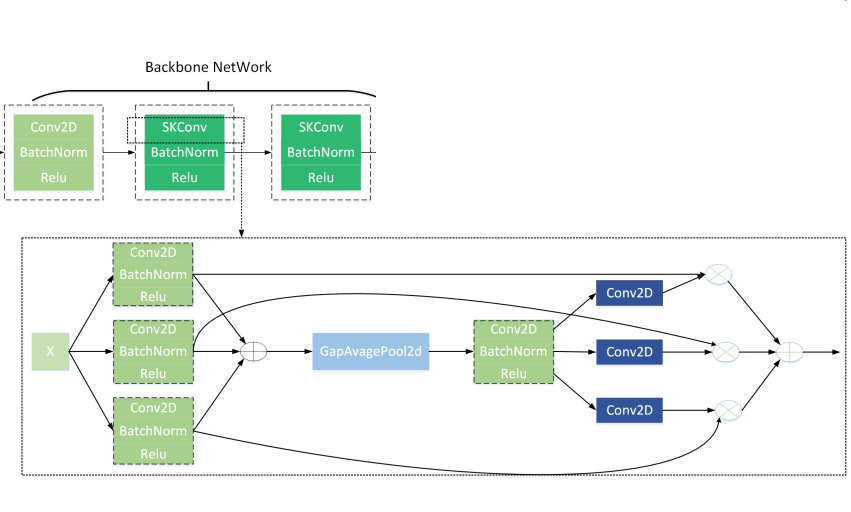

Gao Fig. 1. `Conv64 - SKConv128 - SKConv256 - FC - Softmax` (Sec. III-B).

`Conv64 - SKConv128 - SKConv256 - FC - Softmax` (Gao Sec. III-B).

Layer parameters, from MTHARS Table I:

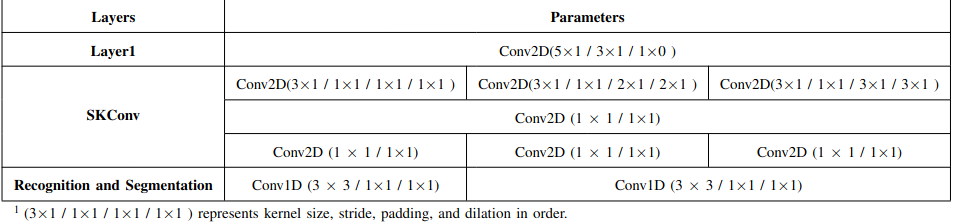

| Layer | kernel / stride / padding / dilation |
|---|---|
| Layer1 | `5x1 / 3x1 / 1x0` |
| SKConv branches | `3x1 / 1x1 / D x1 / D x1` for D = 1, 2, 3 |
| Fuse, Select | `Conv2D(1x1 / 1x1)` |
| Recognition & Segmentation | `Conv1D(3 / 1 / 1)`, twice |

Every kernel is `Nx1`: only the **time** axis is convolved and dilated. The
branch receptive fields of 3, 5 and 7 timesteps are the point of the design, and
softmax attention across those branches is what lets the network prefer a short
receptive field for a brief activity and a long one for a sustained one
(Gao Fig. 6).

Tensor layout is `(B, C, T, S)` -- time on the height axis, sensors on the
width axis. Layer1's stride of 3 is the only temporal downsampling, so it sets
the length `n` of the feature sequence MTHARS builds its windows on.

In [ ]:
backbone = SKNet(in_channels=1, num_classes=6, return_sequence=True).to(device)

example = torch.randn(2, 1, 1024, 9).to(device)   # 1024 timesteps, 9 sensor channels
with torch.inference_mode():
  features = backbone(example)

print(f"stream             {tuple(example.shape)}")
print(f"feature sequence   {tuple(features.shape)}")
print(f"predicted n        {mthars.feature_sequence_length(1024)}")

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"\nSKNet parameters   {count_params(SKNet(num_classes=6)):,}")
print(f"MTHARS parameters  {count_params(MTHARS(num_classes=6)):,}")

# 2. What MTHARS adds

Three pieces sit on top of the feature sequence.

## 2.1 Windows Generate (Duan Sec. III-B)

Anchors, borrowed from SSD. A window is `(x, l)`: centre and length. One is
centred on **every unit** of the feature sequence, and for each scale `s` two
lengths are generated, `n*sqrt(s)` and `n/sqrt(s)`. Dividing through by `n` puts
everything in normalised stream coordinates, so the lengths are simply
`sqrt(s)` and `1/sqrt(s)` and a window means the same thing regardless of how
long the stream is.

With `m` scales that is `n x m x 2` windows. Duan Table VIII: on UCI the best
setting is `s = 2, 3, 4` (F1 0.9723), ahead of `s = 2, 3` (0.9615) and a single
`s = 2` (0.9505).

In [ ]:
n = mthars.feature_sequence_length(1024)
scales = (2.0, 3.0, 4.0)
windows = mthars.generate_windows(n, scales)

print(f"feature sequence length n = {n}")
print(f"windows per centre        = {mthars.windows_per_center(scales)}")
print(f"total anchors             = {windows.shape[0]}  (n x m x 2)")
print(f"\ndistinct lengths (fraction of the stream):")
for length in sorted(set(windows[:, 1].tolist())):
  print(f"  {length:.3f}")

In [ ]:
# Anchors centred on one unit of the feature sequence, drawn over the stream.
fig, ax = plt.subplots(figsize=(11, 3))
centre_index = n // 2
subset = windows[centre_index * mthars.windows_per_center(scales):
                 (centre_index + 1) * mthars.windows_per_center(scales)]

for i, (cx, l) in enumerate(subset.tolist()):
  ax.plot([cx - l / 2, cx + l / 2], [i, i], linewidth=6, solid_capstyle="butt")
  ax.text(cx, i + 0.25, f"l={l:.2f}", ha="center", fontsize=9)

ax.axvline(0, color="black", linestyle=":", linewidth=1)
ax.axvline(1, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("normalised position in the stream (0 = start, 1 = end)")
ax.set_yticks([])
ax.set_title(f"The {mthars.windows_per_center(scales)} anchors at feature unit {centre_index}")
plt.tight_layout()

## 2.2 Matching and offsets (Duan Sec. III-B, Eqs. 1-4)

Each anchor is labelled by the ground-truth activity it overlaps most, measured
by 1-D IoU. Matching runs in two phases: first a greedy bipartite pass takes the
largest entry of the IoU matrix and assigns that pair, discarding its row and
column, until **every** activity owns a window -- so a short activity that no
anchor covers well still gets one. Then every remaining window takes its best
activity if the IoU clears the threshold.

The regression target is the offset between the window and the activity:

- `fx = (tx - wx) / wl`  (Eq. 1)
- `fl = log(tl / wl)`  (Eq. 2)

and inference inverts it, `tx = fx*wl + wx`, `tl = wl*exp(fl)` (Eqs. 3-4).

In [ ]:
# The IoU worked example from Duan Sec. III-B, as a check on the implementation:
# "given windows W1(5, 10), W2(30, 50), and truth activity bounding box T1(40, 60),
#  the IOU of W1 and T1 is 0, and the IOU of W2 and T1 is 0.69."
w = torch.tensor([[5.0, 10.0], [30.0, 50.0]])
t = torch.tensor([[40.0, 60.0]])
print("paper says 0 and 0.69; we get:", [round(v, 4) for v in mthars.iou_1d(w, t).flatten().tolist()])

# Matching two activities against the anchor set.
targets = torch.tensor([[0.25, 0.45], [0.72, 0.5]])   # (centre, length)
labels = torch.tensor([0, 4])
matched_class, matched_box = mthars.match_windows(windows, targets, labels, iou_threshold=0.5)

print(f"\nanchors            {windows.shape[0]}")
print(f"background         {int((matched_class == 0).sum())}")
for i, label in enumerate(labels.tolist()):
  print(f"matched to class {label}: {int((matched_class == label + 1).sum())}")

# Offsets round-trip exactly.
positive = matched_class > 0
offsets = mthars.encode_offsets(matched_box[positive], windows[positive])
recovered = mthars.decode_offsets(offsets, windows[positive])
print(f"\nmax offset round-trip error: {float((recovered - matched_box[positive]).abs().max()):.2e}")

## 2.3 Recognition and Segmentation module (Duan Sec. III-D)

Two convolutional branches over the feature sequence. A fully connected layer
would need a parameter for every one of the `n x m x 2` windows, so instead each
branch is a length-preserving convolution: the predictions for all windows
centred at position `x` live in the channels at position `x` of the output. The
class branch emits `m(k+1)` channels -- class 0 is background -- and the offset
branch `2m`.

The loss is Duan Eq. (8): `L = (1/N)(alpha*L_conf + beta*L_loc)`, SmoothL1 on
the offsets of matched windows and cross-entropy on the classes. Negatives are
mined 3:1 against positives, since almost every anchor is background. Table VII
finds `alpha = beta = 1` best.

In [ ]:
model = MTHARS(num_classes=6, scales=scales).to(device)

streams = torch.randn(4, 1, 1024, 9).to(device)
boxes = [torch.tensor([[0.3, 0.5], [0.8, 0.3]])] * 4
labels = [torch.tensor([0, 4])] * 4

logits, offsets, anchors = model(streams)
print(f"class logits   {tuple(logits.shape)}   (batch, anchors, K+1)")
print(f"offsets        {tuple(offsets.shape)}   (batch, anchors, 2)")
print(f"anchors        {tuple(anchors.shape)}")

total, conf, loc = mthars.multitask_loss(logits, offsets, anchors, boxes, labels,
                                         alpha=1.0, beta=1.0)
print(f"\nloss {float(total):.4f}  =  conf {float(conf):.4f} + loc {float(loc):.4f}")

## 2.4 Inference (Duan Sec. III-B, Algorithm 1)

Softmax over classes, drop background, threshold, then NMS per class on the
decoded boundaries. Algorithm 1 then walks the surviving windows and joins them
into contiguous `(start, end, class)` segments covering the stream.

In [ ]:
# Plant a known activity in the head's output and check it comes back out.
planted = torch.full((1, anchors.shape[0], 7), -10.0, device=device)
planted[0, :, 0] = 10.0            # background everywhere
planted[0, 100, 0] = -10.0
planted[0, 100, 3] = 10.0          # anchor 100 -> class 2
zero_offsets = torch.zeros(1, anchors.shape[0], 2, device=device)

detections = mthars.detect(planted, zero_offsets, anchors, score_threshold=0.5)
print("detected labels:", detections[0]["labels"].tolist())
print("detected box:   ", [round(v, 4) for v in detections[0]["boxes"][0].tolist()])
print("anchor 100:     ", [round(v, 4) for v in anchors[100].tolist()])

painted = mthars.segments_to_labels({k: v.cpu() for k, v in detections[0].items()},
                                    stream_length=1024)
print("\nsegments:", mthars.concatenate_segments(painted))

# 3. Data

UCI-HAR ships **pre-cut** 128-timestep windows, one label each. SKNet consumes
those directly. MTHARS cannot: it needs continuous signal with boundaries to
find.

The windows are shipped in temporal order with 50% overlap, so the stream can be
rebuilt -- take the first window of a run whole, then the second half of each
window after it. `verify_overlap` checks that assumption against the download
instead of trusting it: it measures how far the second half of window *i* is
from the first half of window *i+1*, which should be ~0.

The alternative is the HAPT release (UCI dataset 341), which ships raw
continuous recordings with labelled boundaries. Reconstructing keeps both models
on byte-identical signal, which is what makes the comparison mean anything.

**This is an assumption the papers do not make for you.** Duan reports splitting
UCI 70/30 at random; the official subject-disjoint split is used here instead,
for both models, because a random split leaks subjects between train and test.

In [ ]:
root = har_data.download_uci_har("data")
train_split, test_split = har_data.normalize(har_data.load_split(root, "train"),
                                             har_data.load_split(root, "test"))

print(f"train windows {tuple(train_split.windows.shape)}   "
      f"test windows {tuple(test_split.windows.shape)}")
print(f"subjects: {len(train_split.subjects.unique())} train / "
      f"{len(test_split.subjects.unique())} test (disjoint)")

mismatch = har_data.verify_overlap(train_split)
print(f"\noverlap mismatch between adjacent windows: {mismatch:.3e}")
print("stream reconstruction is valid" if mismatch < 1e-3
      else "*** rows are NOT consecutive overlapping windows; streams are invalid ***")

In [ ]:
STREAM_LENGTH = 1024   # 20.5 s at 50 Hz

train_recordings = har_data.reconstruct_streams(train_split)
test_recordings = har_data.reconstruct_streams(test_split)

train_streams = har_data.StreamDataset(train_recordings, STREAM_LENGTH,
                                       stride=STREAM_LENGTH // 2)
test_streams = har_data.StreamDataset(test_recordings, STREAM_LENGTH)

print(f"reconstructed {len(train_recordings)} train / {len(test_recordings)} test recordings")
print(f"train streams {len(train_streams)}   test streams {len(test_streams)}")

boundaries = [len(s[2]) for s in (test_streams[i] for i in range(len(test_streams)))]
print(f"activities per test stream: min {min(boundaries)}, max {max(boundaries)}, "
      f"mean {sum(boundaries) / len(boundaries):.2f}")

In [ ]:
# A stream that spans an activity transition, with its ground-truth boundaries.
index = next(i for i in range(len(test_streams)) if len(test_streams[i][2]) > 1)
stream, boxes_i, labels_i, timestep_labels = test_streams[index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
for channel in range(3):
  ax1.plot(stream[0, :, channel], linewidth=0.8,
           label=har_data.SIGNALS[channel])
ax1.legend(loc="upper right", fontsize=8)
ax1.set_ylabel("normalised signal")
ax1.set_title(f"Test stream {index}")

for start, end, label in mthars.concatenate_segments(timestep_labels):
  ax2.axvspan(start, end, alpha=0.35)
  ax2.text((start + end) / 2, 0.5, har_data.ACTIVITIES[label],
           ha="center", va="center", fontsize=9)
ax2.set_yticks([])
ax2.set_xlabel("timestep")
ax2.set_ylabel("truth")
plt.tight_layout()

# 4. Training

Both models use Adam with exponentially decaying LR (Gao Sec. IV). `drop_last`
matters: the SK fuse pools to `1x1` before its BatchNorm, so a trailing batch of
one raises an error during training. Inference at batch size 1 is fine.

In [ ]:
import compare
from torch.utils.data import DataLoader

EPOCHS = 30

train_loader = DataLoader(train_streams, batch_size=16, shuffle=True,
                          collate_fn=har_data.collate_streams, drop_last=True)

sknet = compare.train_sknet(train_split, test_split, num_classes=6, device=device,
                            epochs=EPOCHS, batch_size=64)

In [ ]:
mthars_model = compare.train_mthars(train_loader, num_classes=6, device=device,
                                    epochs=EPOCHS, alpha=1.0, beta=1.0, scales=scales)

# 5. Comparison

The two models do different things, so the comparison has to be built carefully.
SKNet classifies a window somebody else cut; MTHARS segments and classifies a
raw stream. Scoring them on **the same held-out streams, per timestep** is what
makes them comparable:

- **SKNet** labels a stream the way the field normally does and the way Duan
  Sec. IV-C argues against: slide a 128-timestep window with 50% overlap,
  classify each, and let overlapping windows vote per timestep.
- **MTHARS** predicts boundaries directly; NMS and concatenation give the
  per-timestep labelling.

Metrics: per-timestep **accuracy**, class-frequency-weighted **F1** (Duan
Eq. 11, since the classes are unbalanced), and **NED** (Eq. 9) -- the edit
distance between the predicted and true activity *sequences*, normalised by
length. NED is the segmentation metric: it is low when the model produces the
right activities in the right order without spurious extra segments.

In [ ]:
results = compare.evaluate_streams(sknet, mthars_model, test_streams, device,
                                   batch_size=16)

print(f"{'model':<10}{'accuracy':>12}{'weighted F1':>14}{'NED':>10}")
for name in ("SKNet", "MTHARS"):
  r = results[name]
  print(f"{name:<10}{r['accuracy']:>12.4f}{r['f1']:>14.4f}{r['ned']:>10.4f}")

delta_f1 = results["MTHARS"]["f1"] - results["SKNet"]["f1"]
delta_acc = results["MTHARS"]["accuracy"] - results["SKNet"]["accuracy"]
delta_ned = results["MTHARS"]["ned"] - results["SKNet"]["ned"]
print(f"\nMTHARS - SKNet:  F1 {delta_f1:+.4f}   accuracy {delta_acc:+.4f}   "
      f"NED {delta_ned:+.4f} (lower is better)")

In [ ]:
# SKNet on its own task, for reference: the shipped 128-timestep windows.
# This is the number Gao's paper quotes; it is NOT comparable to the stream
# numbers above, since the windows are pre-cut and never straddle a transition.
window_results = compare.evaluate_windows(sknet, test_split, device)
print(f"SKNet on pre-cut windows: accuracy {window_results['accuracy']:.4f}, "
      f"F1 {window_results['f1']:.4f}")
print("\nDuan Tables V/VI report on UCI:")
print("  SK      F1 0.9558   accuracy 0.9406")
print("  MTHARS  F1 0.9723   accuracy 0.9632   (+1.65% F1, +2.26% accuracy)")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
names = ["SKNet", "MTHARS"]

for ax, metric, title in zip(axes, ("accuracy", "f1", "ned"),
                             ("Accuracy (higher better)",
                              "Weighted F1 (higher better)",
                              "NED (lower better)")):
  values = [results[n][metric] for n in names]
  ax.bar(names, values)
  ax.set_title(title)
  for i, v in enumerate(values):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
  ax.set_ylim(0, max(values) * 1.25)

plt.tight_layout()

In [ ]:
# Where they differ: truth vs. both predictions on one test stream.
stream, _, _, truth = test_streams[index]

sknet.eval(); mthars_model.eval()
with torch.inference_mode():
  sk_pred = har_data.sliding_window_predict(sknet, stream, device=device)
  logits, offsets, anchors = mthars_model(stream.unsqueeze(0).to(device))
  detection = compare._detect_with_fallback(logits, offsets, anchors, 0.3, 0.45)[0]
  mt_pred = mthars.segments_to_labels({k: v.cpu() for k, v in detection.items()},
                                      stream_length=truth.numel())

fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)
for ax, series, title in zip(axes, (truth, sk_pred, mt_pred),
                             ("ground truth", "SKNet (sliding window)", "MTHARS")):
  for start, end, label in mthars.concatenate_segments(series):
    if label < 0:
      continue
    ax.axvspan(start, end, alpha=0.35)
    if end - start > truth.numel() * 0.06:
      ax.text((start + end) / 2, 0.5, har_data.ACTIVITIES[label],
              ha="center", va="center", fontsize=8)
  ax.set_yticks([]); ax.set_ylabel(title, rotation=0, ha="right", va="center", fontsize=9)

axes[-1].set_xlabel("timestep")
plt.tight_layout()

# 6. Reading these numbers

What the comparison does establish: both models trained on the same signal, and
were scored the same way on the same held-out subjects.

What it does not:

1. **The stream reconstruction is an inference.** UCI-HAR ships windows, not
   streams. `verify_overlap` confirms adjacent rows really do overlap by half,
   but the assumption that consecutive rows of the same subject and activity are
   contiguous in time is still an assumption. Duan does not say how they built
   streams for UCI.
2. **The split differs from the paper's.** Duan splits UCI 70/30 at random; the
   official subject-disjoint split is used here, which is harder and will give
   lower numbers than the paper for both models.
3. **UCI activities are long.** Each run lasts ~60 s, so a 20 s stream usually
   contains one activity and at most one transition. That is close to the easy
   end for a segmentation model; MTHARS has more to gain on datasets whose
   activities are short and varied in length (Duan Fig. 4).
4. **`m` and the scale set matter.** `s = 2, 3, 4` follows Duan Table VIII for
   UCI. The smallest anchor is half the stream, so an activity occupying much
   less than that cannot be matched well -- the paper notes short activities as
   future work.
5. **One run, one seed.** Neither the paper's numbers nor these come with error
   bars; a gap of one or two points is within the noise of a single run.

The honest summary of the architecture question: MTHARS is the SK network plus a
detection head. Anything it gains over SKNet on classification comes from
choosing its own boundaries rather than accepting a fixed window -- which is
exactly the claim in Duan Sec. IV-D, that "precision in obtaining the start and
end positions of the activities can improve the performance of the recognition
activities."